# Phase 1: Dataset Acquisition & Initial Exploration

## 1.1 Load and Inspect

This cell loads the dataset from the local CSV file and displays its structure 
including shape, column names, data types, memory usage, and missing value counts.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")
print(df.head(10))
print(df.info())
print(df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(df.columns)

  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   
5  BMW    1 Series  2012  premium unleaded (required)      230.0   
6  BMW    1 Series  2012  premium unleaded (required)      300.0   
7  BMW    1 Series  2012  premium unleaded (required)      300.0   
8  BMW    1 Series  2012  premium unleaded (required)      230.0   
9  BMW    1 Series  2013  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0    

## Observations from Initial Inspection

The dataset contains **11,914 rows and 16 columns**, covering car specifications 
and pricing data from multiple manufacturers. Out of 16 columns, **8 are numerical** 
(Year, Engine HP, Engine Cylinders, Number of Doors, highway MPG, city mpg, 
Popularity, MSRP) and **8 are categorical** (Make, Model, Engine Fuel Type, 
Transmission Type, Driven_Wheels, Market Category, Vehicle Size, Vehicle Style).

Missing values are present in 5 columns: **Market Category has the most with 
3,742 missing values (31.4%)**, followed by Engine HP (69), Engine Cylinders (30), 
Number of Doors (6), and Engine Fuel Type (3). These will require careful 
imputation strategies.

The dataset occupies approximately **6.08 MB** in memory. The target variables 
identified are **MSRP** (continuous — for regression) and **Vehicle Size** 
(categorical: Compact/Midsize/Large — for classification).

## 1.2 Data Card

| Field | Details |
|---|---|
| **Source URL** | https://www.kaggle.com/datasets/CooperUnion/cardataset |
| **Licence** | CC0 — Public Domain |
| **Collection Method** | Scraped from Edmunds and Twitter; data represents manufacturer-reported specifications |
| **Collection Period** | Model years 1990 to 2017 |
| **Known Limitations** | MSRP reflects original manufacturer price — does not account for depreciation, dealer markups, or regional pricing differences |
| **Sampling Biases** | Dataset is heavily skewed toward US market vehicles and popular brands; rare or regional manufacturers are underrepresented. Older models (pre-2000) have fewer entries than recent years |


## 1.3 Statistical Snapshot

This cell runs `df.describe(include="all")` to generate a full statistical 
summary of all 16 columns — both numerical and categorical — to identify 
skewness, implausible values, and data quality issues before modelling.

In [2]:
df.describe(include="all") # statistical summary of every column

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
count,11914,11914,11914.000000,11911,11845.00000,11884.000000,11914,11914,11908.000000,8172,11914,11914,11914.000000,11914.000000,11914.000000,1.191400e+04
unique,48,915,NaN,10,NaN,NaN,5,4,NaN,71,3,16,NaN,NaN,NaN,NaN
top,Chevrolet,Silverado 1500,NaN,regular unleaded,NaN,NaN,AUTOMATIC,front wheel drive,NaN,Crossover,Compact,Sedan,NaN,NaN,NaN,NaN
freq,1123,156,NaN,7172,NaN,NaN,8266,4787,NaN,1110,4764,3048,NaN,NaN,NaN,NaN
mean,NaN,NaN,2010.384338,NaN,249.38607,5.628829,NaN,NaN,3.436093,NaN,NaN,NaN,26.637485,19.733255,1554.911197,4.059474e+04
std,NaN,NaN,7.579740,NaN,109.19187,1.780559,NaN,NaN,0.881315,NaN,NaN,NaN,8.863001,8.987798,1441.855347,6.010910e+04
min,NaN,NaN,1990.000000,NaN,55.00000,0.000000,NaN,NaN,2.000000,NaN,NaN,NaN,12.000000,7.000000,2.000000,2.000000e+03
25%,NaN,NaN,2007.000000,NaN,170.00000,4.000000,NaN,NaN,2.000000,NaN,NaN,NaN,22.000000,16.000000,549.000000,2.100000e+04
50%,NaN,NaN,2015.000000,NaN,227.00000,6.000000,NaN,NaN,4.000000,NaN,NaN,NaN,26.000000,18.000000,1385.000000,2.999500e+04
75%,NaN,NaN,2016.000000,NaN,300.00000,6.000000,NaN,NaN,4.000000,NaN,NaN,NaN,30.000000,22.000000,2009.000000,4.223125e+04


## Observations from Statistical Snapshot

### Mean vs Median Check (>20% difference flags skewness)

| Column | Mean | Median | Difference % | Flag |
|---|---|---|---|---|
| MSRP | 40,594 | 29,995 | 35.3% | Right-skewed — luxury/exotic cars inflate the mean |
| Engine HP | 249 | 227 | 9.7% |   Acceptable |
| Popularity | 1,554 | 1,385 | 12.2% | Acceptable |
| highway MPG | 26.6 | 26 | 2.3% | Acceptable |
| city mpg | 19.7 | 18 | 9.4% | Acceptable |

### Physically Implausible Values

| Column | Issue | Explanation |
|---|---|---|
| Engine Cylinders | min = **0.0** | No real combustion engine has 0 cylinders — likely electric vehicle recorded incorrectly |
| highway MPG | max = **354** | No conventional car achieves 354 MPG — likely a data entry error |
| city mpg | max = **137** | Implausibly high for a conventional vehicle |
| MSRP | max = **$2,065,902** | Plausible — corresponds to ultra-luxury exotic cars |
| Engine HP | max = **1001** | Plausible — high-performance supercars exceed 1000 HP |

### Key Takeaway
MSRP is heavily right-skewed due to exotic cars and will require log transformation 
before regression modelling. Engine Cylinders minimum of 0 and extremely high MPG 
values will be treated as outliers in Phase 3.

## 1.4 Target Variable Definition

### Regression Target — MSRP
- **Type:** Continuous numerical variable
- **Physical Meaning:** MSRP (Manufacturer's Suggested Retail Price) represents 
the price in US Dollars ($) that a manufacturer recommends a dealer charge for 
a vehicle.
- **Justification:** MSRP is a suitable regression target because it varies 
continuously from $2,000 to $2,065,902 and is directly influenced by engineering 
features such as Engine HP, Engine Cylinders, and fuel efficiency (MPG). 
Predicting MSRP from these features is a meaningful and well-defined 
engineering problem.

### Classification Target — Vehicle Size
- **Type:** Categorical variable with 3 ordered classes
- **Categories:** Compact / Midsize / Large
- **Justification:** Vehicle Size is a natural categorical column already present 
in the dataset — no binning or derivation was required. The three classes 
represent physically meaningful size categories defined by the manufacturer, 
making this a valid and domain-justified classification target.

## 1.5. Class balance check

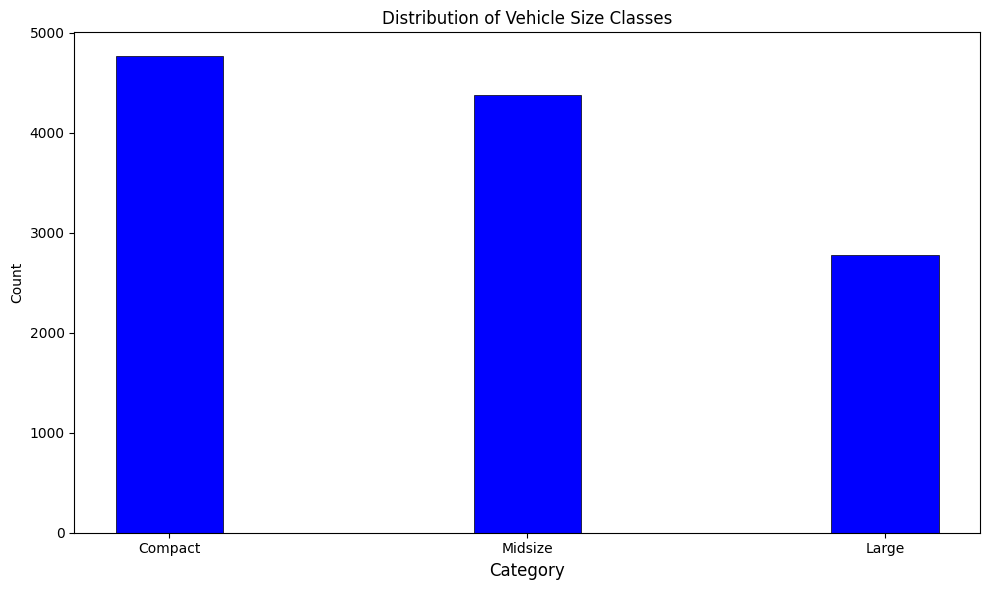

Imbalance ratio: 1.72:1


In [20]:
counts = df["Vehicle Size"].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, width=0.3, color='blue', edgecolor='black', linewidth=0.5)

plt.title("Distribution of Vehicle Size Classes", fontsize=12)
plt.xlabel("Category", fontsize = 12)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Imbalance Ratio
ratio = counts.max() / counts.min()
print(f"Imbalance ratio: {ratio:.2f}:1")

## Class Balance Check

The classification target **Vehicle Size** has the following class distribution:
- **Compact:** 4,764 vehicles (40.0%)
- **Midsize:** 4,028 vehicles (33.8%)
- **Large:** 3,122 vehicles (26.2%)

The imbalance ratio (majority ÷ minority) = **1.72:1**, which is well below the 
5:1 threshold. Therefore, the dataset is **sufficiently balanced** and no special 
handling (such as oversampling or undersampling) is required during model evaluation 
in Phase 7.